In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hocminhle","key":"29d5a2d7248740a6b9e9ae3220f1db6e"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Download BrATS2020 dataset

In [4]:
!kaggle datasets download -d awsaf49/brats2020-training-data
!unzip brats2020-training-data.zip -d /content/brats2020

Streaming output truncated to the last 5000 lines.
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_63.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_64.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_65.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_66.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_67.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_68.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_69.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_7.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_70.h5  
  inflating: /content/brats2020/BraTS2020_training_data/content/data/volume_70_slice_71.h5  
  inflating: /conten

Check dataset folder

In [5]:
import os

for root, dirs, files in os.walk('/content/brats2020'):
    print(root, len(files))
    if len(files) > 0:
        print(files[:5])
        break

/content/brats2020 1
['BraTS20 Training Metadata.csv']


Load .h5 files and create labels

In [6]:
import os
import h5py
import numpy as np
from tqdm import tqdm

data_path = "/content/brats2020/BraTS2020_training_data/content/data"

all_files = sorted([f for f in os.listdir(data_path) if f.endswith(".h5")])

print("Total files:", len(all_files))
print(all_files[:5])

Total files: 57195
['volume_100_slice_0.h5', 'volume_100_slice_1.h5', 'volume_100_slice_10.h5', 'volume_100_slice_100.h5', 'volume_100_slice_101.h5']


In [ ]:
Load .h5 files and create labels

In [18]:
X = []
y = []
sample_masks = []

MAX_SAMPLES = 3000

for file in tqdm(all_files[:MAX_SAMPLES]):
    file_path = os.path.join(data_path, file)

    with h5py.File(file_path, "r") as f:
        image = np.array(f["image"], dtype=np.float32)
        mask = np.array(f["mask"], dtype=np.float32)

    label = 1 if np.max(mask) > 0 else 0

    X.append(image)
    y.append(label)

    # thêm dòng này để lưu mask dùng cho visualization
    if len(sample_masks) < 10:
        sample_masks.append(mask)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Tumor:", np.sum(y == 1))
print("No tumor:", np.sum(y == 0))
print("len sample_masks:", len(sample_masks))

100%|██████████| 3000/3000 [00:38<00:00, 78.30it/s] 


X shape: (3000, 240, 240, 4)
y shape: (3000,)
Tumor: 1228
No tumor: 1772
len sample_masks: 10


Dataset exploration

No Tumor    1772
Tumor       1228
Name: count, dtype: int64


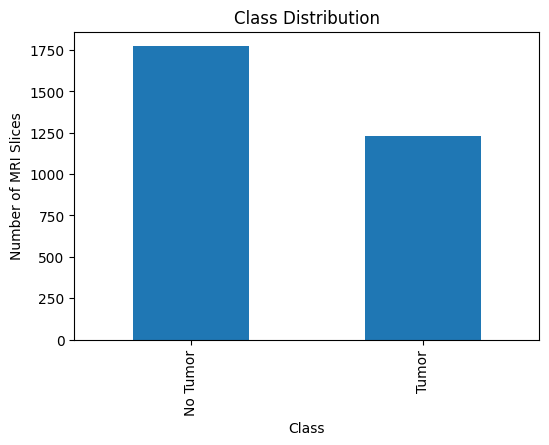

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["No Tumor", "Tumor"]

print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of MRI Slices")
plt.show()

MRI and mask visualization

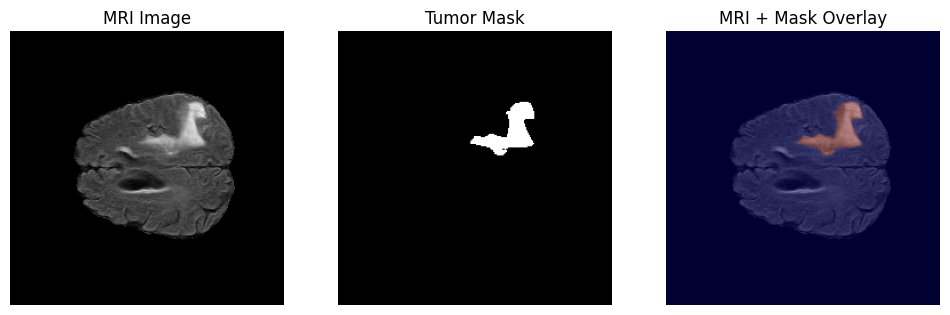

Selected index: 3
File: volume_100_slice_100.h5
Image min/max: -0.5103059 6.537787
Mask max: 1.0


In [21]:
# Chọn ảnh đầu tiên có tumor
idx = np.where(y == 1)[0][0]

# Lấy mask tương ứng trực tiếp từ file gốc
file = all_files[idx]
file_path = os.path.join(data_path, file)

with h5py.File(file_path, "r") as f:
    image = np.array(f["image"], dtype=np.float32)
    mask = np.array(f["mask"], dtype=np.float32)

# Chọn channel MRI để hiển thị
img = image[:, :, 0]

# Normalize để ảnh không bị đen
img_show = (img - img.min()) / (img.max() - img.min() + 1e-8)

# Nếu mask có nhiều channel, gộp lại
if mask.ndim == 3:
    mask_show = np.max(mask, axis=-1)
else:
    mask_show = mask

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_show, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_show, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_show, cmap="gray")
plt.imshow(mask_show, cmap="jet", alpha=0.4)
plt.title("MRI + Mask Overlay")
plt.axis("off")

plt.show()

print("Selected index:", idx)
print("File:", file)
print("Image min/max:", img.min(), img.max())
print("Mask max:", mask_show.max())

Thấy gì trong hình:

MRI image: não hiển thị rõ, không còn đen
Vùng sáng bất thường phía trên -> tumor

Tumor mask: vùng trắng = tumor ground truth
Hình dạng khá rõ + dataset ok

MRI + Mask overlay: overlay màu cam đúng vị trí tumor.
Cho thấy model sau này sẽ học đúng vùng này

Image min/max: -0.51 → 6.53

Mask max: 1.0 -> MRI chưa normalize (sẽ normalize ở bước preprocessing)

Mask là binary (0/1) → chuẩn

Preprocessing

In [24]:
X = X.astype("float32")

X_min = X.min(axis=(1,2,3), keepdims=True)
X_max = X.max(axis=(1,2,3), keepdims=True)

X = (X - X_min) / (X_max - X_min + 1e-8)

if X.shape[-1] > 3:
    X = X[:, :, :, :3]

if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

X_resized = tf.image.resize(X, (224, 224)).numpy()

print("Final X shape:", X_resized.shape)

Final X shape: (3000, 224, 224, 3)


X shape ban đầu: (3000, 240, 240, 4)

→ normalize

→ lấy 3 channel đầu

→ resize về (224, 224, 3)

Final X shape: (3000, 224, 224, 3) đúng input cho MobileNetV2.

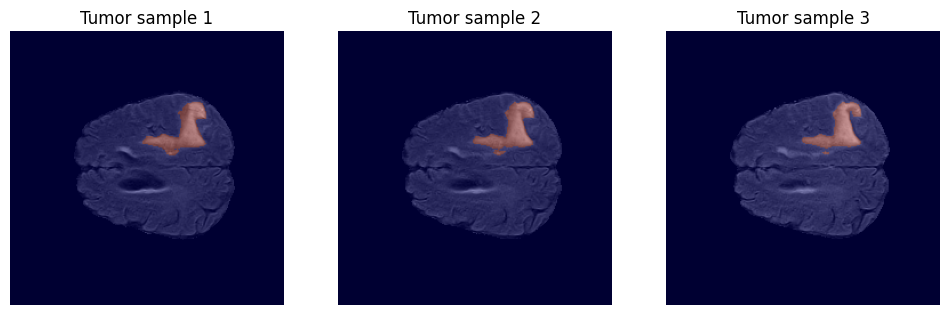

In [25]:
# Hiển thị 3 ảnh tumor khác nhau
tumor_indices = np.where(y == 1)[0][:3]

plt.figure(figsize=(12,4))

for i, idx in enumerate(tumor_indices):
    file = all_files[idx]
    file_path = os.path.join(data_path, file)

    with h5py.File(file_path, "r") as f:
        image = np.array(f["image"])
        mask = np.array(f["mask"])

    img = image[:, :, 0]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    mask = np.max(mask, axis=-1)

    plt.subplot(1,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="jet", alpha=0.4)
    plt.title(f"Tumor sample {i+1}")
    plt.axis("off")

plt.show()

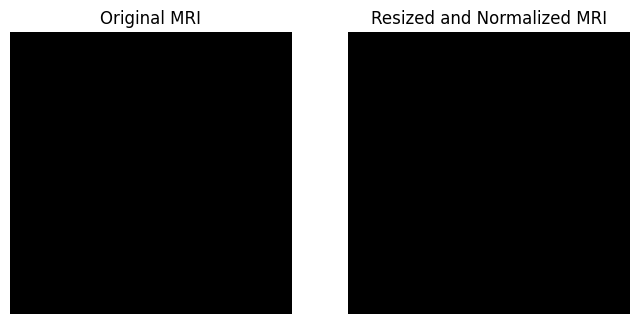

In [27]:
def normalize_for_display(img):
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

orig = normalize_for_display(X[0, :, :, 0])
resized = normalize_for_display(X_resized[0, :, :, 0])

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized, cmap="gray")
plt.title("Resized and Normalized MRI")
plt.axis("off")

plt.show()

Train/test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(2400, 224, 224, 3) (600, 224, 224, 3)


Build transfer learning model

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
import tensorflow as tf

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
embedding = layers.Dense(128, activation="relu", name="embedding")(x)
x = layers.Dropout(0.3)(embedding)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Add Callback

In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_mobilenetv2_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

Train classification head (Initial training)

In [38]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9781 - loss: 0.0720 - val_accuracy: 0.9083 - val_loss: 0.1879 - learning_rate: 1.0000e-07
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9812 - loss: 0.0766 - val_accuracy: 0.9083 - val_loss: 0.1838 - learning_rate: 1.0000e-07
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9797 - loss: 0.0721 - val_accuracy: 0.9146 - val_loss: 0.1793 - learning_rate: 1.0000e-07
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9828 - loss: 0.0694 - val_accuracy: 0.9187 - val_loss: 0.1752 - learning_rate: 1.0000e-07
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9734 - loss: 0.0872 - val_accuracy: 0.9167 - val_loss: 0.1706 - learning_rate: 1.0000e-07
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9792 - loss: 0.0699 - val_accuracy: 0.9208 - val_loss: 0.1666 - learning_rate: 1.0000e-07
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9807 

Fine-tuning

In [39]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.9724 - loss: 0.0738 - val_accuracy: 0.9396 - val_loss: 0.1387 - learning_rate: 1.0000e-05
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9911 - loss: 0.0448 - val_accuracy: 0.9500 - val_loss: 0.1329 - learning_rate: 1.0000e-05
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9880 - loss: 0.0441 - val_accuracy: 0.9500 - val_loss: 0.1296 - learning_rate: 1.0000e-05
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9927 - loss: 0.0307 - val_accuracy: 0.9563 - val_loss: 0.1218 - learning_rate: 1.0000e-05
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9927 - loss: 0.0280 - val_accuracy: 0.9563 - val_loss: 0.1204 - learning_rate: 1.0000e-05
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9958 - loss: 0.0199 - val_accuracy: 0.9563 - val_loss: 0.1213 - learning_rate: 1.0000e-05
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.995

Training Curves

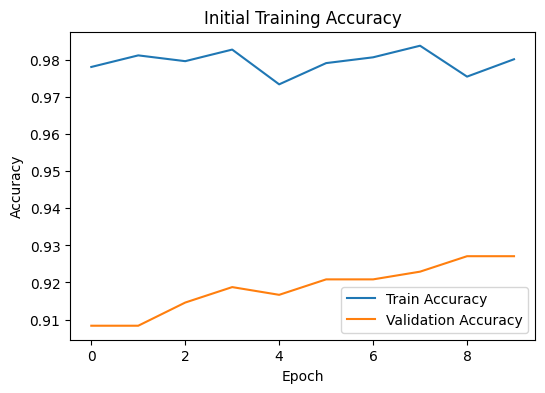

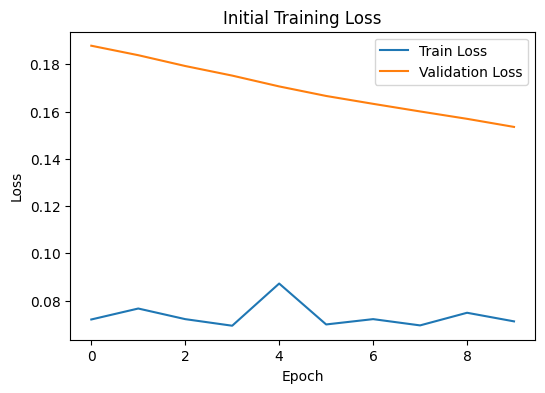

In [40]:
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Accuracy**

Train: ~0.98

Val: ~0.91 → 0.927

-> Model học tốt nhưng còn gap giữa train và validation

**Loss**

Train loss thấp (~0.07)

Val loss giảm đều (~0.18 → 0.15)

-> training ổn định

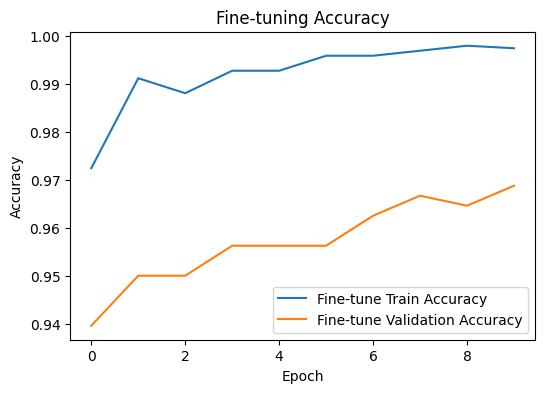

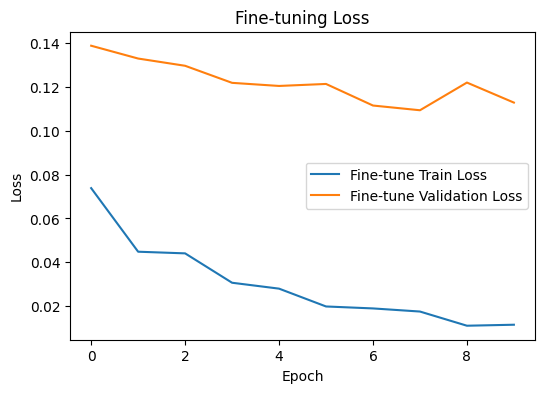

In [41]:
plt.figure(figsize=(6,4))
plt.plot(history_finetune.history["accuracy"], label="Fine-tune Train Accuracy")
plt.plot(history_finetune.history["val_accuracy"], label="Fine-tune Validation Accuracy")
plt.title("Fine-tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_finetune.history["loss"], label="Fine-tune Train Loss")
plt.plot(history_finetune.history["val_loss"], label="Fine-tune Validation Loss")
plt.title("Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Accuracy**

Train: ~0.97 → 0.997 (rất cao)

Val: ~0.94 → 0.9688 (rất tốt)

-> Fine-tuning giúp tăng performance rõ rệt (~+4%)

**Loss**

Train loss: giảm mạnh (~0.07 → 0.01)

Val loss: giảm (~0.14 → ~0.11) nhưng hơi dao động

-> Model bắt đầu overfit nhẹ (train quá tốt)

In [45]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       354
           1       0.92      0.95      0.93       246

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



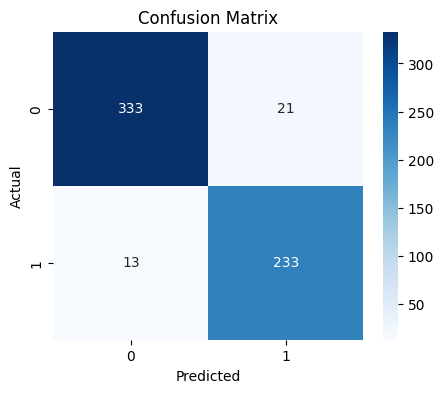

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve

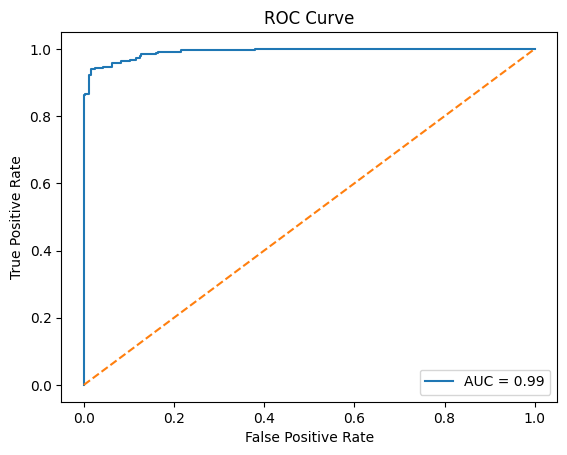

In [47]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

AUC ≈ 0.99 -> model good

Evaluate fine-tuned CNN

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred, target_names=["No Tumor", "Tumor"]))

cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

cnn_acc = accuracy_score(y_test, y_pred)
cnn_precision = precision_score(y_test, y_pred)
cnn_recall = recall_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred)
cnn_specificity = tn / (tn + fp)

print("CNN Accuracy:", cnn_acc)
print("CNN Precision:", cnn_precision)
print("CNN Recall/Sensitivity:", cnn_recall)
print("CNN Specificity:", cnn_specificity)
print("CNN F1-score:", cnn_f1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
              precision    recall  f1-score   support

    No Tumor       0.96      0.94      0.95       354
       Tumor       0.92      0.95      0.93       246

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600

[[333  21]
 [ 13 233]]
CNN Accuracy: 0.9433333333333334
CNN Precision: 0.9173228346456693
CNN Recall/Sensitivity: 0.9471544715447154
CNN Specificity: 0.940677966101695
CNN F1-score: 0.932


Confusion matrix visualization

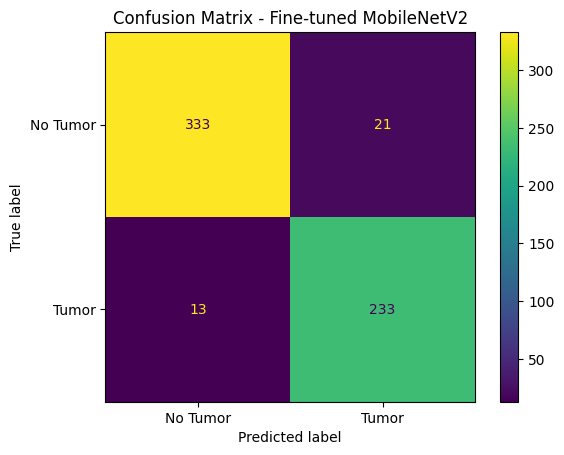

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("Confusion Matrix - Fine-tuned MobileNetV2")
plt.show()

Extract embeddings from trained model

In [50]:
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding").output
)

train_embeddings = embedding_model.predict(X_train)
test_embeddings = embedding_model.predict(X_test)

print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)

75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step
Train embeddings: (2400, 128)
Test embeddings: (600, 128)


Apply PCA dimensionality reduction

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(train_embeddings)
X_test_pca = pca.transform(test_embeddings)

print("Before PCA:", train_embeddings.shape)
print("After PCA:", X_train_pca.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Before PCA: (2400, 128)
After PCA: (2400, 50)
Explained variance: 0.98451316


PCA explained variance plot

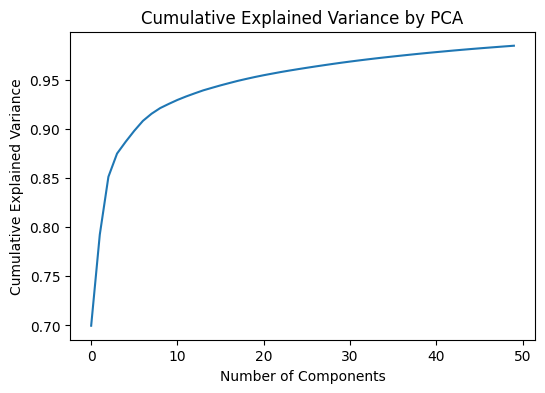

In [52]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Cumulative Explained Variance by PCA")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

PCA 2D visualization

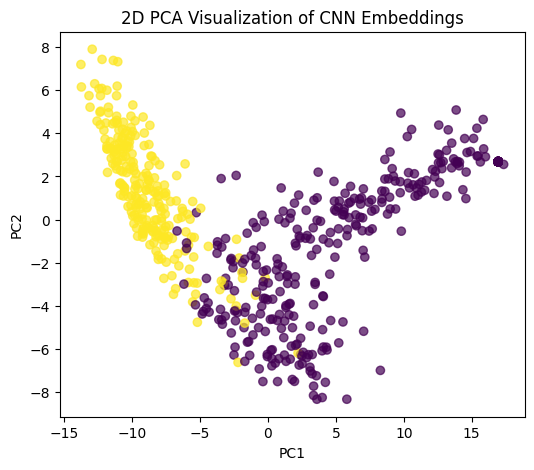

In [53]:
pca_2d = PCA(n_components=2)
X_test_2d = pca_2d.fit_transform(test_embeddings)

plt.figure(figsize=(6,5))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, alpha=0.7)
plt.title("2D PCA Visualization of CNN Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Train SVM using PCA features

In [54]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", probability=True)

svm_model.fit(X_train_pca, y_train)

y_pred_pca = svm_model.predict(X_test_pca)

print(classification_report(y_test, y_pred_pca, target_names=["No Tumor", "Tumor"]))

              precision    recall  f1-score   support

    No Tumor       0.96      0.96      0.96       354
       Tumor       0.94      0.95      0.94       246

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



Evaluate PCA + SVM

In [55]:
cm_pca = confusion_matrix(y_test, y_pred_pca)
print(cm_pca)

tn, fp, fn, tp = cm_pca.ravel()

pca_acc = accuracy_score(y_test, y_pred_pca)
pca_precision = precision_score(y_test, y_pred_pca)
pca_recall = recall_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca)
pca_specificity = tn / (tn + fp)

print("PCA + SVM Accuracy:", pca_acc)
print("PCA + SVM Precision:", pca_precision)
print("PCA + SVM Recall/Sensitivity:", pca_recall)
print("PCA + SVM Specificity:", pca_specificity)
print("PCA + SVM F1-score:", pca_f1)

[[339  15]
 [ 13 233]]
PCA + SVM Accuracy: 0.9533333333333334
PCA + SVM Precision: 0.9395161290322581
PCA + SVM Recall/Sensitivity: 0.9471544715447154
PCA + SVM Specificity: 0.9576271186440678
PCA + SVM F1-score: 0.9433198380566802


PCA + SVM confusion matrix

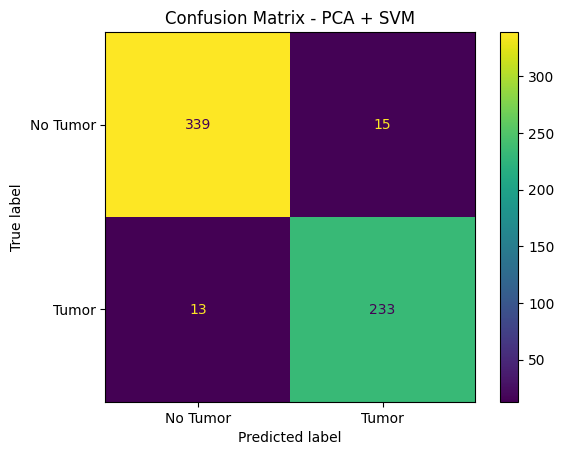

In [56]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pca,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("Confusion Matrix - PCA + SVM")
plt.show()

Final comparison table

In [57]:
results = pd.DataFrame({
    "Model": [
        "Fine-tuned MobileNetV2",
        "MobileNetV2 Embedding + PCA + SVM"
    ],
    "Accuracy": [
        cnn_acc,
        pca_acc
    ],
    "Precision": [
        cnn_precision,
        pca_precision
    ],
    "Recall/Sensitivity": [
        cnn_recall,
        pca_recall
    ],
    "Specificity": [
        cnn_specificity,
        pca_specificity
    ],
    "F1-score": [
        cnn_f1,
        pca_f1
    ]
})

results

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score
0,Fine-tuned MobileNetV2,0.943333,0.917323,0.947154,0.940678,0.93200
1,MobileNetV2 Embedding + PCA + SVM,0.953333,0.939516,0.947154,0.957627,0.94332


Save model and results to Google Drive

In [58]:
import os

save_path = "/content/drive/MyDrive/Brain_Tumor_Project"
os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "fine_tuned_mobilenetv2_brain_tumor.keras"))
results.to_csv(os.path.join(save_path, "comparison_results.csv"), index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Brain_Tumor_Project
